# DeepPoly MNIST Robustness Bounds

This notebook is a compact robustness-certification experiment on MNIST. It compares a normally trained multilayer perceptron against the same architecture trained with a DeepPoly-based robustness objective.

**Certification target.** For each test image, we consider all pixel perturbations inside an `L_inf` ball of radius `epsilon`. DeepPoly propagates lower and upper bounds through the network and proves robustness when the true class lower bound is larger than every wrong class upper bound:

`lower[y] > upper[j]` for every `j != y`.

All reported certification results are computed over multiple test images (`CERT_LIMIT`), not a single selected example.


In [1]:
import gzip
import random
import struct
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = Path("mnist")
BASELINE_MODEL_PATH = Path("mnist_baseline.pt")
ROBUST_MODEL_PATH = Path("mnist_deeppoly_robust.pt")

RESET_MODELS = True  # set False after one full run to reuse saved weights

EPSILON = 0.05
EVAL_EPSILONS = [0.00, 0.01, 0.03, 0.05]

TRAIN_LIMIT = 12000
ROBUST_TRAIN_LIMIT = 12000
CERT_LIMIT = 500

BASELINE_EPOCHS = 8
ROBUST_EPOCHS = 12
BASELINE_BATCH = 128
ROBUST_BATCH = 32
BASELINE_LR = 1e-3
ROBUST_LR = 5e-4
ROBUST_LAMBDA = 0.12

print(f"device={DEVICE}")

device=cpu


In [2]:
BASE_URL = "https://ossci-datasets.s3.amazonaws.com/mnist"
MNIST_FILES = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz",
]


def ensure_mnist(data_dir=DATA_DIR):
    data_dir.mkdir(exist_ok=True)
    for filename in MNIST_FILES:
        raw_path = data_dir / filename[:-3]
        gz_path = data_dir / filename
        if raw_path.exists():
            continue

        print(f"downloading {filename}")
        urllib.request.urlretrieve(f"{BASE_URL}/{filename}", gz_path)
        with gzip.open(gz_path, "rb") as src, open(raw_path, "wb") as dst:
            dst.write(src.read())
        gz_path.unlink()


def read_images(path):
    with open(path, "rb") as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"bad image file: {path}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows * cols).astype(np.float32) / 255.0


def read_labels(path):
    with open(path, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"bad label file: {path}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.astype(np.int64)


def load_mnist(data_dir=DATA_DIR):
    ensure_mnist(data_dir)
    x_train = read_images(data_dir / "train-images-idx3-ubyte")
    y_train = read_labels(data_dir / "train-labels-idx1-ubyte")
    x_test = read_images(data_dir / "t10k-images-idx3-ubyte")
    y_test = read_labels(data_dir / "t10k-labels-idx1-ubyte")

    x_train = torch.from_numpy(x_train).to(DEVICE)
    y_train = torch.from_numpy(y_train).to(DEVICE)
    x_test = torch.from_numpy(x_test).to(DEVICE)
    y_test = torch.from_numpy(y_test).to(DEVICE)
    return x_train, y_train, x_test, y_test


X_train, y_train, X_test, y_test = load_mnist()
print(f"train={tuple(X_train.shape)}  test={tuple(X_test.shape)}")

train=(60000, 784)  test=(10000, 784)


In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        return self.layers(x)


def batched_indices(n, batch_size, shuffle=True):
    if shuffle:
        order = torch.randperm(n, device=DEVICE)
    else:
        order = torch.arange(n, device=DEVICE)
    for start in range(0, n, batch_size):
        yield order[start:start + batch_size]


@torch.no_grad()
def clean_accuracy(model, x, y, limit=None, batch_size=512):
    model.eval()
    if limit is not None:
        x = x[:limit]
        y = y[:limit]
    correct = 0
    total = 0
    for idx in batched_indices(len(x), batch_size, shuffle=False):
        pred = model(x[idx]).argmax(dim=1)
        correct += (pred == y[idx]).sum().item()
        total += len(idx)
    return correct / total


def train_clean(model, x, y, epochs, batch_size, lr, limit):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    x = x[:limit]
    y = y[:limit]

    for epoch in range(1, epochs + 1):
        losses = []
        model.train()
        for idx in batched_indices(len(x), batch_size, shuffle=True):
            logits = model(x[idx])
            loss = F.cross_entropy(logits, y[idx])
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        acc = clean_accuracy(model, X_test, y_test, limit=1000)
        print(f"clean epoch {epoch:02d}/{epochs}  loss={np.mean(losses):.4f}  test_acc_1k={100 * acc:.2f}%")


def save_model(model, path):
    torch.save(model.state_dict(), path)


def load_model(path):
    model = MLP().to(DEVICE)
    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state)
    return model

In [4]:
def eval_symbolic(lb_coef, ub_coef, lb_bias, ub_bias, inp_l, inp_u):
    lower = lb_bias + torch.where(lb_coef >= 0, lb_coef * inp_l[:, None, :], lb_coef * inp_u[:, None, :]).sum(dim=2)
    upper = ub_bias + torch.where(ub_coef >= 0, ub_coef * inp_u[:, None, :], ub_coef * inp_l[:, None, :]).sum(dim=2)
    return lower, upper


def dp_first_linear(layer, inp_l, inp_u):
    W = layer.weight
    b = layer.bias
    batch = inp_l.shape[0]
    lb_coef = W.unsqueeze(0).expand(batch, -1, -1)
    ub_coef = W.unsqueeze(0).expand(batch, -1, -1)
    lb_bias = b.unsqueeze(0).expand(batch, -1)
    ub_bias = b.unsqueeze(0).expand(batch, -1)
    lower, upper = eval_symbolic(lb_coef, ub_coef, lb_bias, ub_bias, inp_l, inp_u)
    return lb_coef, ub_coef, lb_bias, ub_bias, lower, upper


def dp_linear(prev, layer, inp_l, inp_u):
    prev_lbc, prev_ubc, prev_lbb, prev_ubb, _, _ = prev
    W = layer.weight
    b = layer.bias
    W_pos = torch.clamp(W, min=0.0)
    W_neg = torch.clamp(W, max=0.0)

    lb_coef = torch.einsum("on,bnd->bod", W_pos, prev_lbc) + torch.einsum("on,bnd->bod", W_neg, prev_ubc)
    ub_coef = torch.einsum("on,bnd->bod", W_pos, prev_ubc) + torch.einsum("on,bnd->bod", W_neg, prev_lbc)
    lb_bias = torch.einsum("on,bn->bo", W_pos, prev_lbb) + torch.einsum("on,bn->bo", W_neg, prev_ubb) + b
    ub_bias = torch.einsum("on,bn->bo", W_pos, prev_ubb) + torch.einsum("on,bn->bo", W_neg, prev_lbb) + b

    lower, upper = eval_symbolic(lb_coef, ub_coef, lb_bias, ub_bias, inp_l, inp_u)
    return lb_coef, ub_coef, lb_bias, ub_bias, lower, upper


def dp_relu(prev):
    prev_lbc, prev_ubc, prev_lbb, prev_ubb, lower, upper = prev
    zeros_coef = torch.zeros_like(prev_lbc)
    zeros_bias = torch.zeros_like(prev_lbb)

    positive = lower >= 0
    negative = upper <= 0
    mixed = ~(positive | negative)

    use_identity_lower = positive | (mixed & (upper > -lower))
    denom = torch.clamp(upper - lower, min=1e-12)
    slope = torch.where(mixed, upper / denom, torch.ones_like(upper))
    intercept = torch.where(mixed, -upper * lower / denom, torch.zeros_like(upper))

    lb_coef = torch.where(use_identity_lower[:, :, None], prev_lbc, zeros_coef)
    lb_bias = torch.where(use_identity_lower, prev_lbb, zeros_bias)

    mixed_ubc = slope[:, :, None] * prev_ubc
    mixed_ubb = slope * prev_ubb + intercept
    ub_coef = torch.where(positive[:, :, None], prev_ubc, torch.where(mixed[:, :, None], mixed_ubc, zeros_coef))
    ub_bias = torch.where(positive, prev_ubb, torch.where(mixed, mixed_ubb, zeros_bias))

    relu_lower = torch.where(use_identity_lower, lower, torch.zeros_like(lower))
    relu_upper = torch.where(positive | mixed, upper, torch.zeros_like(upper))
    return lb_coef, ub_coef, lb_bias, ub_bias, relu_lower, relu_upper


def deeppoly_bounds(model, x, epsilon):
    inp_l = torch.clamp(x - epsilon, 0.0, 1.0)
    inp_u = torch.clamp(x + epsilon, 0.0, 1.0)

    layers = list(model.layers)
    curr = None
    for layer in layers:
        if isinstance(layer, nn.Linear):
            curr = dp_first_linear(layer, inp_l, inp_u) if curr is None else dp_linear(curr, layer, inp_l, inp_u)
        elif isinstance(layer, nn.ReLU):
            curr = dp_relu(curr)
        else:
            raise TypeError(f"unsupported layer: {layer}")

    return curr[4], curr[5]


def bound_components(lower, upper, y):
    true_lower = lower.gather(1, y[:, None]).squeeze(1)
    wrong_mask = F.one_hot(y, num_classes=10).bool()
    max_wrong_upper = upper.masked_fill(wrong_mask, -1e9).max(dim=1).values
    margin = true_lower - max_wrong_upper
    return true_lower, max_wrong_upper, margin


def certified_margin(lower, upper, y):
    return bound_components(lower, upper, y)[2]


def deeppoly_robust_loss(model, x, y, epsilon):
    lower, upper = deeppoly_bounds(model, x, epsilon)
    true_lower = lower.gather(1, y[:, None]).squeeze(1)
    wrong_mask = F.one_hot(y, num_classes=10).bool()
    smooth_wrong_upper = torch.logsumexp(upper.masked_fill(wrong_mask, -1e9), dim=1)
    return F.softplus(smooth_wrong_upper - true_lower).mean()


@torch.no_grad()
def certification_details(model, x, y, epsilon, limit=CERT_LIMIT, batch_size=32):
    model.eval()
    x = x[:limit]
    y = y[:limit]

    labels = []
    preds = []
    true_lowers = []
    max_wrong_uppers = []
    margins = []

    for idx in batched_indices(len(x), batch_size, shuffle=False):
        xb = x[idx]
        yb = y[idx]
        pred = model(xb).argmax(dim=1)
        lower, upper = deeppoly_bounds(model, xb, epsilon)
        true_lower, max_wrong_upper, margin = bound_components(lower, upper, yb)

        labels.append(yb.detach().cpu())
        preds.append(pred.detach().cpu())
        true_lowers.append(true_lower.detach().cpu())
        max_wrong_uppers.append(max_wrong_upper.detach().cpu())
        margins.append(margin.detach().cpu())

    labels = torch.cat(labels)
    preds = torch.cat(preds)
    true_lowers = torch.cat(true_lowers)
    max_wrong_uppers = torch.cat(max_wrong_uppers)
    margins = torch.cat(margins)

    return pd.DataFrame({
        "label": labels.numpy(),
        "pred": preds.numpy(),
        "true_lower": true_lowers.numpy(),
        "max_wrong_upper": max_wrong_uppers.numpy(),
        "margin": margins.numpy(),
        "clean_correct": (preds == labels).numpy(),
        "certified": (margins > 0).numpy(),
    })


@torch.no_grad()
def certification_report(model, x, y, epsilons, limit=CERT_LIMIT, batch_size=32):
    rows = []

    for epsilon in epsilons:
        details = certification_details(model, x, y, epsilon, limit=limit, batch_size=batch_size)
        rows.append({
            "epsilon": epsilon,
            "samples": len(details),
            "clean_acc": details["clean_correct"].mean(),
            "certified_acc": details["certified"].mean(),
            "avg_margin": details["margin"].mean(),
            "min_margin": details["margin"].min(),
        })

    return pd.DataFrame(rows)


@torch.no_grad()
def per_digit_bound_summary(model, x, y, epsilon, limit=CERT_LIMIT, batch_size=32):
    details = certification_details(model, x, y, epsilon, limit=limit, batch_size=batch_size)
    rows = []

    for digit in range(10):
        subset = details[details["label"] == digit]
        samples = len(subset)
        rows.append({
            "digit": digit,
            "samples": samples,
            "clean_acc": subset["clean_correct"].mean() if samples else np.nan,
            "certified_acc": subset["certified"].mean() if samples else np.nan,
            "avg_true_lower": subset["true_lower"].mean() if samples else np.nan,
            "avg_max_wrong_upper": subset["max_wrong_upper"].mean() if samples else np.nan,
            "avg_margin": subset["margin"].mean() if samples else np.nan,
            "min_margin": subset["margin"].min() if samples else np.nan,
        })

    return pd.DataFrame(rows)


## 1. Baseline Model

The baseline model is trained only with cross-entropy. After training, we evaluate clean accuracy and certified accuracy across several epsilon values. This gives the unrobust reference point.


In [5]:
if BASELINE_MODEL_PATH.exists() and not RESET_MODELS:
    baseline_model = load_model(BASELINE_MODEL_PATH)
else:
    baseline_model = MLP().to(DEVICE)
    train_clean(baseline_model, X_train, y_train, BASELINE_EPOCHS, BASELINE_BATCH, BASELINE_LR, TRAIN_LIMIT)
    save_model(baseline_model, BASELINE_MODEL_PATH)

print(f"baseline_test_acc={100 * clean_accuracy(baseline_model, X_test, y_test):.2f}%")
print(f"certification_samples={CERT_LIMIT}")
display(certification_report(baseline_model, X_test, y_test, EVAL_EPSILONS).style.format({
    "epsilon": "{:.3f}",
    "clean_acc": "{:.2%}",
    "certified_acc": "{:.2%}",
    "avg_margin": "{:.4f}",
    "min_margin": "{:.4f}",
}))


clean epoch 01/8  loss=1.2495  test_acc_1k=84.90%
clean epoch 02/8  loss=0.4078  test_acc_1k=88.30%
clean epoch 03/8  loss=0.3041  test_acc_1k=90.20%
clean epoch 04/8  loss=0.2582  test_acc_1k=91.00%
clean epoch 05/8  loss=0.2263  test_acc_1k=91.60%
clean epoch 06/8  loss=0.2011  test_acc_1k=91.90%
clean epoch 07/8  loss=0.1794  test_acc_1k=92.80%
clean epoch 08/8  loss=0.1591  test_acc_1k=92.90%
baseline_test_acc=93.64%
certification_samples=500


,epsilon,samples,clean_acc,certified_acc,avg_margin,min_margin
0,0.000,500,94.20%,94.20%,4.3557,-7.1438
1,0.010,500,94.20%,85.20%,2.8598,-8.4941
2,0.030,500,94.20%,35.60%,-1.1413,-11.7892
3,0.050,500,94.20%,3.80%,-6.3916,-15.7538


## 2. DeepPoly Robust Training

The robust model starts from the baseline weights and continues training with an additional DeepPoly loss. The objective is:

`cross_entropy + lambda * DeepPoly_bound_loss`

The bound loss penalizes cases where the strongest wrong-class upper bound is above the true-class lower bound. In other words, training tries to increase the certification margin.


In [6]:
def train_deeppoly_robust(model, x, y, epochs, batch_size, lr, epsilon, lam, limit):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    x = x[:limit]
    y = y[:limit]

    for epoch in range(1, epochs + 1):
        current_eps = epsilon * epoch / epochs
        clean_losses = []
        robust_losses = []

        model.train()
        for idx in batched_indices(len(x), batch_size, shuffle=True):
            xb = x[idx]
            yb = y[idx]
            logits = model(xb)
            clean_loss = F.cross_entropy(logits, yb)
            robust_loss = deeppoly_robust_loss(model, xb, yb, current_eps)
            loss = clean_loss + lam * robust_loss

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            clean_losses.append(clean_loss.item())
            robust_losses.append(robust_loss.item())

        acc = clean_accuracy(model, X_test, y_test, limit=1000)
        print(
            f"robust epoch {epoch:02d}/{epochs}  eps={current_eps:.4f}  "
            f"clean_loss={np.mean(clean_losses):.4f}  "
            f"robust_loss={np.mean(robust_losses):.4f}  "
            f"test_acc_1k={100 * acc:.2f}%"
        )


if ROBUST_MODEL_PATH.exists() and not RESET_MODELS:
    robust_model = load_model(ROBUST_MODEL_PATH)
else:
    robust_model = MLP().to(DEVICE)
    robust_model.load_state_dict(baseline_model.state_dict())
    train_deeppoly_robust(
        robust_model,
        X_train,
        y_train,
        ROBUST_EPOCHS,
        ROBUST_BATCH,
        ROBUST_LR,
        EPSILON,
        ROBUST_LAMBDA,
        ROBUST_TRAIN_LIMIT,
    )
    save_model(robust_model, ROBUST_MODEL_PATH)

print(f"robust_test_acc={100 * clean_accuracy(robust_model, X_test, y_test):.2f}%")
print(f"certification_samples={CERT_LIMIT}")
display(certification_report(robust_model, X_test, y_test, EVAL_EPSILONS).style.format({
    "epsilon": "{:.3f}",
    "clean_acc": "{:.2%}",
    "certified_acc": "{:.2%}",
    "avg_margin": "{:.4f}",
    "min_margin": "{:.4f}",
}))

robust epoch 01/12  eps=0.0042  clean_loss=0.1496  robust_loss=0.2010  test_acc_1k=92.20%
robust epoch 02/12  eps=0.0083  clean_loss=0.1363  robust_loss=0.2539  test_acc_1k=93.10%
robust epoch 03/12  eps=0.0125  clean_loss=0.1274  robust_loss=0.3332  test_acc_1k=93.10%
robust epoch 04/12  eps=0.0167  clean_loss=0.1162  robust_loss=0.4294  test_acc_1k=93.30%
robust epoch 05/12  eps=0.0208  clean_loss=0.1103  robust_loss=0.5505  test_acc_1k=93.40%
robust epoch 06/12  eps=0.0250  clean_loss=0.1045  robust_loss=0.6691  test_acc_1k=93.00%
robust epoch 07/12  eps=0.0292  clean_loss=0.1033  robust_loss=0.7858  test_acc_1k=93.60%
robust epoch 08/12  eps=0.0333  clean_loss=0.1030  robust_loss=0.9004  test_acc_1k=94.10%
robust epoch 09/12  eps=0.0375  clean_loss=0.1043  robust_loss=1.0088  test_acc_1k=94.00%
robust epoch 10/12  eps=0.0417  clean_loss=0.1060  robust_loss=1.1033  test_acc_1k=93.70%
robust epoch 11/12  eps=0.0458  clean_loss=0.1084  robust_loss=1.1968  test_acc_1k=93.40%
robust epo

,epsilon,samples,clean_acc,certified_acc,avg_margin,min_margin
0,0.000,500,95.00%,95.00%,5.3023,-6.4986
1,0.010,500,95.00%,92.00%,4.4356,-7.4080
2,0.030,500,95.00%,78.60%,2.4776,-9.3745
3,0.050,500,95.00%,52.60%,0.1205,-11.7713


## 3. Many-Image Bound Summary by Digit

The next two tables summarize certification behavior by true digit over the evaluated test images.

- `clean_acc`: fraction classified correctly without perturbation.
- `certified_acc`: fraction provably robust at the selected epsilon.
- `avg_true_lower`: average DeepPoly lower bound for the correct class.
- `avg_max_wrong_upper`: average largest upper bound among incorrect classes.
- `avg_margin`: average value of `true_lower - max_wrong_upper`; positive is better.
- `min_margin`: worst certification margin observed in that digit group.


In [10]:
baseline_digit_bounds = per_digit_bound_summary(baseline_model, X_test, y_test, EPSILON)
trained_digit_bounds = per_digit_bound_summary(robust_model, X_test, y_test, EPSILON)

print(f"epsilon={EPSILON}  samples={CERT_LIMIT}")
print("Before DeepPoly robust training: baseline many-image bounds")
display(baseline_digit_bounds.style.format({
    "clean_acc": "{:.2%}",
    "certified_acc": "{:.2%}",
    "avg_true_lower": "{:.4f}",
    "avg_max_wrong_upper": "{:.4f}",
    "avg_margin": "{:.4f}",
    "min_margin": "{:.4f}",
}))

print("After DeepPoly robust training: trained many-image bounds")
display(trained_digit_bounds.style.format({
    "clean_acc": "{:.2%}",
    "certified_acc": "{:.2%}",
    "avg_true_lower": "{:.4f}",
    "avg_max_wrong_upper": "{:.4f}",
    "avg_margin": "{:.4f}",
    "min_margin": "{:.4f}",
}))


epsilon=0.05  samples=500
Before DeepPoly robust training: baseline many-image bounds
After DeepPoly robust training: trained many-image bounds


,digit,samples,clean_acc,certified_acc,avg_true_lower,avg_max_wrong_upper,avg_margin,min_margin
0,0,42,97.62%,21.43%,-0.0599,2.7564,-2.8162,-10.9944
1,1,67,100.00%,0.00%,-3.0666,4.7452,-7.8118,-13.8989
2,2,55,89.09%,5.45%,0.1594,4.6009,-4.4416,-13.7412
3,3,45,97.78%,2.22%,-0.4672,4.6140,-5.0813,-10.2231
4,4,55,94.55%,1.82%,-2.0476,5.7221,-7.7697,-15.7538
5,5,50,92.00%,4.00%,-1.5500,4.3213,-5.8712,-15.5160
6,6,43,88.37%,6.98%,-1.5113,4.6177,-6.1290,-15.3127
7,7,49,93.88%,0.00%,-1.6904,5.5039,-7.1943,-13.5906
8,8,40,95.00%,0.00%,-2.1011,3.6971,-5.7983,-11.1147
9,9,54,92.59%,0.00%,-3.7660,5.7211,-9.4871,-15.6269


,digit,samples,clean_acc,certified_acc,avg_true_lower,avg_max_wrong_upper,avg_margin,min_margin
0,0,42,100.00%,78.57%,2.6710,0.1056,2.5654,-4.1839
1,1,67,100.00%,85.07%,2.3384,0.6482,1.6901,-3.6121
2,2,55,94.55%,45.45%,2.2443,2.6568,-0.4125,-8.8264
3,3,45,97.78%,68.89%,2.0647,0.8155,1.2492,-6.0343
4,4,55,94.55%,30.91%,0.3244,1.7611,-1.4366,-10.0947
5,5,50,90.00%,30.00%,0.0619,1.6128,-1.5509,-11.7713
6,6,43,90.70%,72.09%,2.4461,0.5884,1.8578,-10.0910
7,7,49,93.88%,36.73%,1.5673,2.4513,-0.8840,-7.8012
8,8,40,92.50%,32.50%,0.1136,0.9770,-0.8633,-7.0047
9,9,54,94.44%,42.59%,0.1397,0.8754,-0.7357,-7.4351


## 4. Aggregate Certification Summary

This table is the main before/after result at the selected epsilon. `certified_acc` is the percentage of evaluated images for which DeepPoly proves robustness.


In [8]:
def final_aggregate_summary(baseline_model, robust_model, epsilon):
    rows = []
    for name, model in [("baseline", baseline_model), ("deeppoly_trained", robust_model)]:
        cert = certification_report(model, X_test, y_test, [epsilon], limit=CERT_LIMIT).iloc[0]
        rows.append({
            "model": name,
            "epsilon": epsilon,
            "samples": int(cert["samples"]),
            "clean_acc": cert["clean_acc"],
            "certified_acc": cert["certified_acc"],
            "avg_margin": cert["avg_margin"],
            "min_margin": cert["min_margin"],
        })
    return pd.DataFrame(rows)


summary = final_aggregate_summary(baseline_model, robust_model, EPSILON)
display(summary.style.format({
    "epsilon": "{:.3f}",
    "clean_acc": "{:.2%}",
    "certified_acc": "{:.2%}",
    "avg_margin": "{:.4f}",
    "min_margin": "{:.4f}",
}))


,model,epsilon,samples,clean_acc,certified_acc,avg_margin,min_margin
0,baseline,0.050,500,94.20%,3.80%,-6.3916,-15.7538
1,deeppoly_trained,0.050,500,95.00%,52.60%,0.1205,-11.7713


## 5. Certification Curve

This plot shows how certified accuracy changes as epsilon increases. Larger epsilon means a larger perturbation set, so certification usually becomes harder.


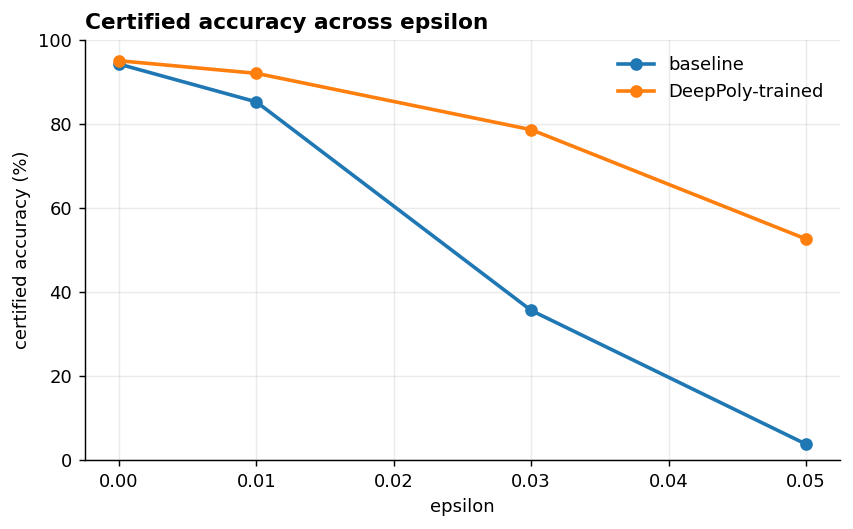

In [9]:
baseline_eps_report = certification_report(baseline_model, X_test, y_test, EVAL_EPSILONS)
trained_eps_report = certification_report(robust_model, X_test, y_test, EVAL_EPSILONS)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(
    baseline_eps_report["epsilon"],
    100 * baseline_eps_report["certified_acc"],
    marker="o",
    linewidth=2,
    label="baseline",
)
ax.plot(
    trained_eps_report["epsilon"],
    100 * trained_eps_report["certified_acc"],
    marker="o",
    linewidth=2,
    label="DeepPoly-trained",
)
ax.set_title("Certified accuracy across epsilon", loc="left", fontweight="semibold")
ax.set_xlabel("epsilon")
ax.set_ylabel("certified accuracy (%)")
ax.set_ylim(0, 100)
ax.legend(frameon=False)
plt.show()


## 6. Limitations

This notebook is intended as a clear educational implementation, not a reproduction of the full DeepPoly paper results.

- The model is a small fully connected MNIST network.
- Certification is evaluated on `CERT_LIMIT` test images for runtime reasons.
- The perturbation model is `L_inf` pixel noise only.
- Certified accuracy is a formal guarantee for the specified epsilon, but only for this network, dataset, and perturbation model.
- Empirical attack accuracy and certified robustness are different metrics; this notebook focuses on certification.
